# **Tiền Xử lí dữ liệu**

<a id="toc"></a>
# **MỤC LỤC**
***

**1. <a href='#1'>KHỞI TẠO VÀ TẢI DỮ LIỆU</a>**
> * <a href='#1.1'>1.1. Tải thư viện</a>
> * <a href='#1.2'>1.2. Đọc dữ liệu</a>

**2. <a href='#2'>TỔNG QUAN DỮ LIỆU</a>**
> * <a href='#2.1'>2.1. Kiểm tra tổng quan (Info, Null, Types)</a>
> * <a href='#2.2'>2.2. Phân tích phân phối & Outlier</a>

**3. <a href='#3'>XỬ LÝ DỮ LIỆU</a>**
> * <a href='#3.1'>3.1. Làm sạch dữ liệu</a>
> * <a href='#3.2'>3.2. Feature Engineering</a>
> * <a href='#3.3'>3.3. Xử lý Outlier</a>
> * <a href='#3.4'>3.4. Mã hóa và Chuẩn hóa</a>
> * <a href='#3.5'>3.5. Xử lí đa cộng tuyến</a>
> * <a href='#3.6'>3.6. Chọn lọc thuộc tính</a>

**4. <a href='#4'>PHÂN TÍCH TƯƠNG QUAN</a>**

**5. <a href='#5'>XUẤT DỮ LIỆU</a>**

***

***

## <a id='1'>1. Khởi tạo và Tải dữ liệu</a> 


### <a id='1.1'>1.1. Tải thư viện</a> 
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Bước đầu tiên là nhập các thư viện cần thiết cho việc xử lý dữ liệu (Pandas, Numpy) và trực quan hóa cơ bản (Matplotlib, Seaborn). Sau đó, chúng ta sẽ tải bộ dữ liệu `WA_Fn-UseC_-HR-Employee-Attrition.csv` vào DataFrame.

In [14]:
#TODO 1: Nhập thư viện và dữ liệu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import warnings

### <a id='1.2'>1.2. Đọc dữ liệu</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

In [15]:
#TODO 2: Đọc dữ liệu
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

file_path = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
df = pd.read_csv(file_path)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## <a id='2'>2. Tổng quan dữ liệu và tìm ngoại lai</a>


### <a id='2.1'>2.1. Tổng quan dữ liệu</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Trước khi xử lý, ta cần nắm bắt kích thước dữ liệu, kiểu dữ liệu của từng thuộc tính và kiểm tra sơ bộ các giá trị thống kê. Điều này giúp xác định xem dữ liệu có chứa giá trị null hay không và định dạng đã chuẩn chưa.

In [16]:
#TODO 3: Tổng quan dữ liệu 
# Kiểm tra kích thước dữ liệu (số dòng, số cột)
print(f"Kích thước dataset: {df.shape}")

# Kiểm tra thông tin kiểu dữ liệu và giá trị thiếu (null)
df.info()

# Thống kê mô tả cho các biến định lượng
df.describe()

Kích thước dataset: (1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### <a id='2.2'>2.2. Phân tích phân phối và phát hiện ngoại lai</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>
Trước khi đi vào xử lý chi tiết, nhóm tiến hành kiểm tra phân phối của các biến định lượng quan trọng như `MonthlyIncome` (Thu nhập), `TotalWorkingYears` (Tổng số năm đi làm), và `YearsAtCompany` (Thâm niên).

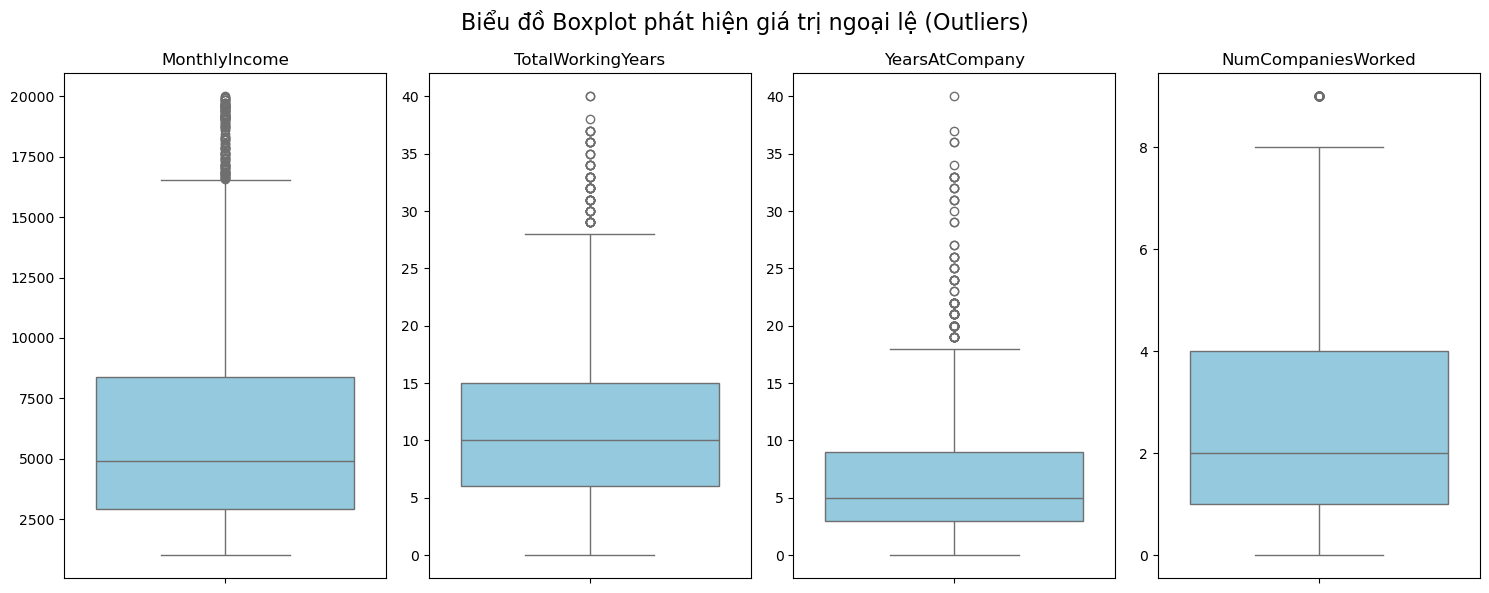

Biến 'MonthlyIncome': Phát hiện 114 giá trị ngoại lệ (>16581.0)
Biến 'TotalWorkingYears': Phát hiện 63 giá trị ngoại lệ (>28.5)
Biến 'YearsAtCompany': Phát hiện 104 giá trị ngoại lệ (>18.0)
Biến 'NumCompaniesWorked': Phát hiện 52 giá trị ngoại lệ (>8.5)


In [17]:
#TODO 4: Phân phối và phát hiện ngoại lai
# Chọn các biến định lượng liên tục (Continuous variables) 
# Đây là các biến thường có outlier
continuous_vars = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'NumCompaniesWorked']

# Vẽ biểu đồ Boxplot để trực quan hóa Outliers
plt.figure(figsize=(15, 6))
plt.suptitle("Biểu đồ Boxplot phát hiện giá trị ngoại lệ (Outliers)", fontsize=16)

for i, col in enumerate(continuous_vars):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
    plt.ylabel('')

plt.tight_layout()
plt.show()

# Tính toán số lượng Outlier dựa trên IQR (để đưa vào báo cáo)
for col in continuous_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = df[df[col] > upper_bound].shape[0]
    print(f"Biến '{col}': Phát hiện {outliers_count} giá trị ngoại lệ (>{upper_bound})")

**Nhận xét:**
* **MonthlyIncome:** Xuất hiện nhiều điểm ngoại lai (Outliers) ở phía trên. Điều này phản ánh thực tế là một số ít nhân viên (Quản lý cấp cao, Giám đốc) có mức lương vượt trội so với mặt bằng chung.
* **YearsAtCompany & TotalWorkingYears:** Cũng có đuôi dài về phía giá trị lớn, đại diện cho nhóm nhân viên thâm niên cao.
* **Quyết định xử lý:** Vì chúng ta sẽ sử dụng các mô hình cây (như Random Forest) có khả năng chịu nhiễu tốt, và nhóm lương cao/thâm niên cao là nhóm quan trọng cần giữ chân, nên ta sẽ **không xóa bỏ** các dòng này mà sử dụng phương pháp **Capping (chặn trên)** hoặc giữ nguyên tùy theo thuật toán được chọn ở bước sau.

## <a id='3'>3. Xử lí dữ liệu</a>


### <a id='3.1'>3.1. Làm sạch dữ liệu</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Dựa trên kết quả kiểm tra sơ bộ, quy trình làm sạch dữ liệu bao gồm:
1.  **Xử lý giá trị thiếu (Null):** Kiểm tra lại lần cuối, nếu có sẽ điền bằng giá trị trung bình (Mean).
2.  **Xử lý trùng lặp:** Loại bỏ các dòng dữ liệu bị trùng hoàn toàn (Duplicate rows).
3.  **Loại bỏ thuộc tính vô nghĩa:** Xóa các cột có phương sai bằng 0 (chỉ có 1 giá trị duy nhất) như `EmployeeCount`, `StandardHours`, `Over18` và cột định danh `EmployeeNumber` không có giá trị dự báo.


In [18]:
#TODO 5: Xóa các cột không nhiều ảnh hưởng đến dữ liệu và tìm các dữ liệu bị thiếu
# 1. Kiểm tra null
if df.isnull().sum().sum() == 0:
    print("Dữ liệu sạch, không có giá trị thiếu (Null).")
else:
    df.fillna(df.mean(), inplace=True) # Điền mean nếu có (dự phòng)

# 2. Xóa trùng lặp
df.drop_duplicates(inplace=True)

# 3. Xóa cột thừa
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 4. Mã hóa biến mục tiêu 'Attrition' ngay từ đầu để tiện phân tích
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

print(f"Kích thước sau khi làm sạch: {df.shape}")

Dữ liệu sạch, không có giá trị thiếu (Null).
Kích thước sau khi làm sạch: (1470, 31)


## <a id='3.2'>3.2. Kỹ thuật tạo đặc trưng</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Dựa trên kiến thức nghiệp vụ (Domain Knowledge), nhóm thực hiện tạo thêm các biến phái sinh để làm nổi bật các mẫu (patterns) tiềm ẩn:

* **Các chỉ số tương đối:**
    * `Income_Rel_Role`: Tỷ lệ lương so với mức trung bình của vị trí đó (phát hiện người bị trả lương thấp).
    * `Income_Distance`: Tỷ lệ giữa thu nhập và khoảng cách đi làm (Trade-off).
    * `PromotionStagnation`: Mức độ trì trệ thăng tiến (Số năm không thăng chức / Thâm niên).
    * `Loyalty`: Chỉ số trung thành (Thâm niên tại cty / Tổng số năm đi làm).
    * `Stability`: Độ ổn định vị trí (Năm ở vị trí hiện tại / Thâm niên tại cty).

* **Các chỉ số tổng hợp:**
    * `TotalSatisfaction`: Điểm hài lòng trung bình (Môi trường + Công việc + Quan hệ + Cân bằng cuộc sống).

* **Các nhóm nhân viên đặc thù (Biến Binary 0/1):**
    * `SalesDpt`: Nhân viên thuộc phòng Sales (thường áp lực cao).
    * `JobInvCut`: Nhóm ít tham gia vào công việc (JobInvolvement < 2.5).
    * `MoovingPeople`: Nhóm hay nhảy việc (đã làm > 4 công ty).
    * `LongDisJobS1`: Nhóm rủi ro (Nhà xa > 11km VÀ Không hài lòng công việc).
    * `YoungAndBadPaid`: Nhóm rủi ro cao (Trẻ tuổi < 35 VÀ Lương thấp < 3500$).
    * `Engaged`: Nhóm ổn định (Tuổi > 35 VÀ Đã kết hôn).

* **Phân nhóm (Binning):**
    * `AgeGroup`: Nhóm tuổi (Young, Middle, Senior).
    * `IncomeRange`: Nhóm thu nhập (Low, Medium, High, Very High).

In [19]:
#TODO 6: Tạo đặc trưng mới
# Tỷ lệ thu nhập so với mức trung bình của vị trí (JobRole)
df['AvgIncome_Role'] = df.groupby('JobRole')['MonthlyIncome'].transform('mean')
df['Income_Rel_Role'] = df['MonthlyIncome'] / df['AvgIncome_Role']

# Mức độ "trì trệ" thăng tiến (Số năm không thăng chức / Thâm niên)
df['PromotionStagnation'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)

# Chỉ số trung thành (Loyalty)
df['Loyalty'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)

# Tổng hợp mức độ hài lòng (Engagement Score)
df['TotalSatisfaction'] = (df['EnvironmentSatisfaction'] + 
                           df['JobSatisfaction'] + 
                           df['RelationshipSatisfaction'] + 
                           df['WorkLifeBalance']) / 4

# Độ ổn định công việc (Stability)
df['Stability'] = df['YearsInCurrentRole'] / (df['YearsAtCompany'] + 1e-5)


# Thuộc phòng Sales (Thường áp lực cao)
df['SalesDpt'] = (df['Department'] == 'Sales').astype(int)

# Ít tham gia công việc (< 2.5)
df['JobInvCut'] = (df['JobInvolvement'] < 2.5).astype(int)

# Người hay nhảy việc (> 4 công ty)
df['MoovingPeople'] = (df['NumCompaniesWorked'] > 4).astype(int)

# Nhóm rủi ro: Nhà xa (>11km) VÀ Không hài lòng công việc (Mức 1)
df['LongDisJobS1'] = ((df['DistanceFromHome'] > 11) & (df['JobSatisfaction'] == 1)).astype(int)

# Nhóm rủi ro: Trẻ tuổi (23-35) VÀ Lương thấp (<3500)
df['YoungAndBadPaid'] = ((df['Age'] > 23) & (df['Age'] < 35) & (df['MonthlyIncome'] < 3500)).astype(int)

# Nhóm ổn định: Tuổi > 35 và Đã kết hôn/Có gia đình
df['Engaged'] = ((df['Age'] > 35) & (df['MaritalStatus'] != 'Single')).astype(int)

# Tỷ lệ Thu nhập trên Khoảng cách đi lại
df['Income_Distance'] = df['MonthlyIncome'] / (df['DistanceFromHome'] + 1)


# Nhóm độ tuổi
df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 30, 45, 60], labels=['Young', 'Middle', 'Senior'])

# Nhóm thu nhập
df['IncomeRange'] = pd.qcut(df['MonthlyIncome'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

# Xóa cột trung gian
df.drop(columns=['AvgIncome_Role'], inplace=True, errors='ignore')

print("Đã hoàn thành tạo đặc trưng mới.")
display(df[['Income_Rel_Role', 'PromotionStagnation', 'YoungAndBadPaid', 'AgeGroup']].head())
display(df.head())

Đã hoàn thành tạo đặc trưng mới.


,Income_Rel_Role,PromotionStagnation,YoungAndBadPaid,AgeGroup
0,0.865505,0.000000,0,Middle
1,1.583347,0.090909,0,Senior
2,0.645626,0.000000,0,Middle
3,0.897847,0.333333,1,Middle
4,1.071306,0.666667,1,Young


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Income_Rel_Role,PromotionStagnation,Loyalty,TotalSatisfaction,Stability,SalesDpt,JobInvCut,MoovingPeople,LongDisJobS1,YoungAndBadPaid,Engaged,Income_Distance,AgeGroup,IncomeRange
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5,0.865505,0.000000,0.666667,2.00,0.666666,1,0,1,0,0,0,2996.500000,Middle,High
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7,1.583347,0.090909,0.909091,3.00,0.699999,0,1,0,0,0,1,570.000000,Senior,High
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0,0.645626,0.000000,0.000000,3.00,0.000000,0,1,1,0,0,0,696.666667,Middle,Low
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0,0.897847,0.333333,0.888889,3.25,0.874999,0,0,0,0,1,0,727.250000,Middle,Low
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2,1.071306,0.666667,0.285714,2.50,0.999995,0,0,1,0,1,0,1156.000000,Young,Medium


## <a id='3.3'>3.3. Xử lý Ngoại lệ (Outliers) & Phân phối lệch (Skewness)</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Từ biểu đồ Boxplot, ta thấy các biến định lượng có nhiều giá trị ngoại lai phía trên (thu nhập quá cao, thâm niên quá lớn). Để giảm thiểu tác động xấu đến mô hình nhưng không làm mất dữ liệu, nhóm sử dụng phương pháp **Capping (Chặn trên)** dựa trên IQR:

* **Ngưỡng chặn trên (Upper Bound):** $Q3 + 1.5 \times IQR$
* Các giá trị vượt quá ngưỡng này sẽ được gán bằng giá trị ngưỡng.
* Áp dụng cho các biến: `MonthlyIncome`, `TotalWorkingYears`, `YearsAtCompany`, `NumCompaniesWorked`.

In [20]:
#TODO 7: Xử lí ngoại lệ
# Hàm xử lý ngoại lệ
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    # Chỉ xử lý cận trên (Upper) vì dữ liệu nhân sự thường bị lệch về phía cao
    return series.clip(upper=upper_bound)

# Áp dụng cho các cột đã phát hiện ở Mục 2
cols_with_outliers = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'NumCompaniesWorked']

for col in cols_with_outliers:
    df[col] = cap_outliers(df[col])

print(f"Đã hoàn tất xử lý ngoại lệ cho các biến: {cols_with_outliers}")

Đã hoàn tất xử lý ngoại lệ cho các biến: ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'NumCompaniesWorked']


## <a id='3.4'>3.4. Mã hóa & Chuẩn hóa dữ liệu</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Để chuẩn bị dữ liệu cho các thuật toán Machine Learning, nhóm thực hiện:

1.  **Mã hóa One-Hot (One-Hot Encoding):**
    * Chuyển đổi các biến phân loại (`BusinessTravel`, `Department`, `JobRole`...) thành các cột số nhị phân (0/1).
    * Sử dụng `drop_first=True` để giảm số chiều và tránh hiện tượng đa cộng tuyến hoàn hảo (Dummy Variable Trap).

2.  **Lưu trữ bản chưa chuẩn hóa (`df_not_scaled`):**
    * Giữ lại một bản sao dữ liệu gốc sau khi mã hóa nhưng chưa scale. Dữ liệu này rất hữu ích cho các mô hình dạng Cây (Decision Tree, Random Forest) vì giữ nguyên được ý nghĩa thực tế của giá trị (ví dụ: Lương = 5000$).

3.  **Chuẩn hóa (Standard Scaling):**
    * Áp dụng `StandardScaler` cho các biến liên tục (có nhiều hơn 2 giá trị duy nhất) để đưa về phân phối chuẩn (Mean=0, Std=1).
    * Việc này giúp các thuật toán tính khoảng cách (như KNN, SVM, Logistic Regression) hoạt động tốt hơn.

In [21]:
from sklearn.preprocessing import StandardScaler
#TODO 8: Chuẩn hóa dữ liệu và mã hóa
# 1. MÃ HÓA ONE-HOT (Tạo ra các cột True/False)
# drop_first=True: Rất quan trọng để tránh đa cộng tuyến
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. CHUYỂN ĐỔI TRUE/FALSE SANG 1/0
# Đảm bảo máy tính hiểu đúng định dạng số
df_encoded = df_encoded.astype(float) 
df_not_scaled = df_encoded.copy()
# 3. CHUẨN HÓA (STANDARD SCALING) 
# Tạo danh sách các cột cần scale (Rate, Age, Income...)
# Logic: Chỉ scale các biến liên tục (nhiều hơn 2 giá trị), KHÔNG scale biến 0/1 (vì 0/1 đã chuẩn rồi)
cols_to_scale = [col for col in df_encoded.columns 
                 if col != 'Attrition'                 
                 and df_encoded[col].nunique() > 2]    

print(f"Đang chuẩn hóa {len(cols_to_scale)} cột bằng StandardScaler...")

# Dùng StandardScaler
scaler = StandardScaler()
df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

# Hiển thị kết quả để kiểm chứng
# Bạn sẽ thấy giá trị có cả số âm (ví dụ -1.2, 0.5...) -> Đây là đặc trưng của Standard
print("\n--- Kiểm tra dữ liệu sau khi chuẩn hóa (StandardScaler) ---")
print(df_encoded[['DailyRate', 'Age', 'MonthlyIncome', 'SalesDpt']].head())
df_encoded.head()

Đang chuẩn hóa 28 cột bằng StandardScaler...

--- Kiểm tra dữ liệu sau khi chuẩn hóa (StandardScaler) ---
   DailyRate       Age  MonthlyIncome  SalesDpt
0   0.742527  0.446350      -0.084766       1.0
1  -1.297775  1.322365      -0.283072       0.0
2   1.414363  0.008343      -0.981623       0.0
3   1.461466 -0.429664      -0.793428       0.0
4  -0.524295 -1.086676      -0.664977       0.0


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Income_Rel_Role,PromotionStagnation,Loyalty,TotalSatisfaction,Stability,SalesDpt,JobInvCut,MoovingPeople,LongDisJobS1,YoungAndBadPaid,Engaged,Income_Distance,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,AgeGroup_Middle,AgeGroup_Senior,IncomeRange_Medium,IncomeRange_High,IncomeRange_Very High
0,0.446350,1.0,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.084766,0.726020,2.169877,-1.150554,3.0,-1.584178,-0.932014,-0.424999,-2.171982,-2.493820,-0.123832,-0.063296,-0.679146,0.245834,-0.390426,-0.878153,0.298323,-1.445591,0.266525,1.0,0.0,1.0,0.0,0.0,0.0,1.062556,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0
1,1.322365,0.0,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.283072,1.488876,-0.682817,2.129306,4.0,1.191438,0.241988,-0.151076,0.155707,0.338096,0.678078,0.764998,-0.368715,0.806541,1.693404,-0.540536,1.150791,0.532090,0.366973,0.0,1.0,0.0,0.0,0.0,1.0,-0.444103,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.008343,1.0,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.981623,-1.674841,1.354822,-0.057267,3.0,-0.658973,-0.932014,-0.561960,0.155707,0.338096,-1.326697,-1.167687,-0.679146,-1.155935,-1.028717,-0.878153,-2.045965,0.532090,-1.742399,0.0,1.0,1.0,0.0,0.0,0.0,-0.365453,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
3,-0.429664,0.0,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.793428,1.243211,-0.682817,-1.150554,3.0,0.266233,-0.932014,-0.424999,0.155707,0.338096,0.277123,0.764998,0.252146,-1.155935,-0.296541,0.359776,1.079752,1.026511,0.894315,0.0,0.0,0.0,0.0,1.0,0.0,-0.346463,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,-1.086676,0.0,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.664977,0.325900,2.373641,-0.877232,3.0,1.191438,0.241988,-0.698921,0.155707,0.338096,-0.925742,-0.615492,-0.058285,-0.595227,0.206995,1.597706,-1.041270,-0.456750,1.270977,0.0,0.0,1.0,0.0,1.0,0.0,-0.080244,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## <a id='3.5'>3.5. Xử lí đa cộng tuyến</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Đa cộng tuyến (Multicollinearity) xảy ra khi các biến đầu vào có mối tương quan quá mạnh với nhau, làm giảm độ ổn định của mô hình.

* **Phương pháp:** Tính ma trận tương quan giữa các biến độc lập.
* **Ngưỡng xử lý:** Nếu hệ số tương quan giữa 2 biến **> 0.8**, sẽ loại bỏ một trong hai biến.
* **Thực hiện:** Loại bỏ các biến vi phạm khỏi cả tập dữ liệu đã chuẩn hóa (`df_encoded`) và chưa chuẩn hóa (`df_not_scaled`).

In [22]:
# TODO: Xử lý Đa cộng tuyến (Multicollinearity)
# Mục đích: Loại bỏ các biến có tương quan quá cao với nhau (>0.85) vì chúng mang thông tin giống nhau.

# 1. Tách biến mục tiêu ra để không bị ảnh hưởng
X_temp = df_encoded.drop('Attrition', axis=1)

# 2. Tính ma trận tương quan (lấy giá trị tuyệt đối)
corr_matrix = X_temp.corr().abs()

# 3. Chọn phần tam giác trên của ma trận tương quan (để không kiểm tra trùng lặp)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Tìm các cột có tương quan lớn hơn ngưỡng (threshold = 0.85)
# Bạn có thể điều chỉnh 0.85 thành 0.8 hoặc 0.9 tùy nhu cầu
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

print(f"--- PHÁT HIỆN ĐA CỘNG TUYẾN ---")
print(f"-> Số lượng biến bị loại bỏ: {len(to_drop)}")
print(f"-> Danh sách biến bị loại bỏ: {to_drop}")

# 5. Loại bỏ các cột này khỏi dữ liệu chính (df_encoded)
df_encoded.drop(columns=to_drop, axis=1, inplace=True)

# 6. Đồng bộ xóa luôn ở df_not_scaled (nếu có) để phục vụ bước xuất file sau này
if 'df_not_scaled' in locals():
    df_not_scaled.drop(columns=to_drop, axis=1, inplace=True, errors='ignore')
    print("-> Đã đồng bộ xóa các cột này trong 'df_not_scaled'.")

print(f"\n-> Kích thước dữ liệu sau khi xử lý: {df_encoded.shape}")

--- PHÁT HIỆN ĐA CỘNG TUYẾN ---
-> Số lượng biến bị loại bỏ: 9
-> Danh sách biến bị loại bỏ: ['MonthlyIncome', 'YearsInCurrentRole', 'YearsWithCurrManager', 'JobInvCut', 'MoovingPeople', 'Department_Research & Development', 'Department_Sales', 'JobRole_Sales Executive', 'IncomeRange_Very High']
-> Đã đồng bộ xóa các cột này trong 'df_not_scaled'.

-> Kích thước dữ liệu sau khi xử lý: (1470, 53)


## <a id='3.6'>3.6. Chọn lọc thuộc tính</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>


Sử dụng thuật toán **Random Forest Classifier** (với tham số `class_weight='balanced'` để xử lý mất cân bằng mẫu) nhằm đánh giá mức độ quan trọng của từng đặc trưng.

* Mục tiêu: Xác định Top các đặc trưng đóng góp nhiều nhất vào khả năng dự báo nghỉ việc.
* Kết quả: Biểu đồ dưới đây hiển thị Top 25 đặc trưng quan trọng nhất (Feature Importance).

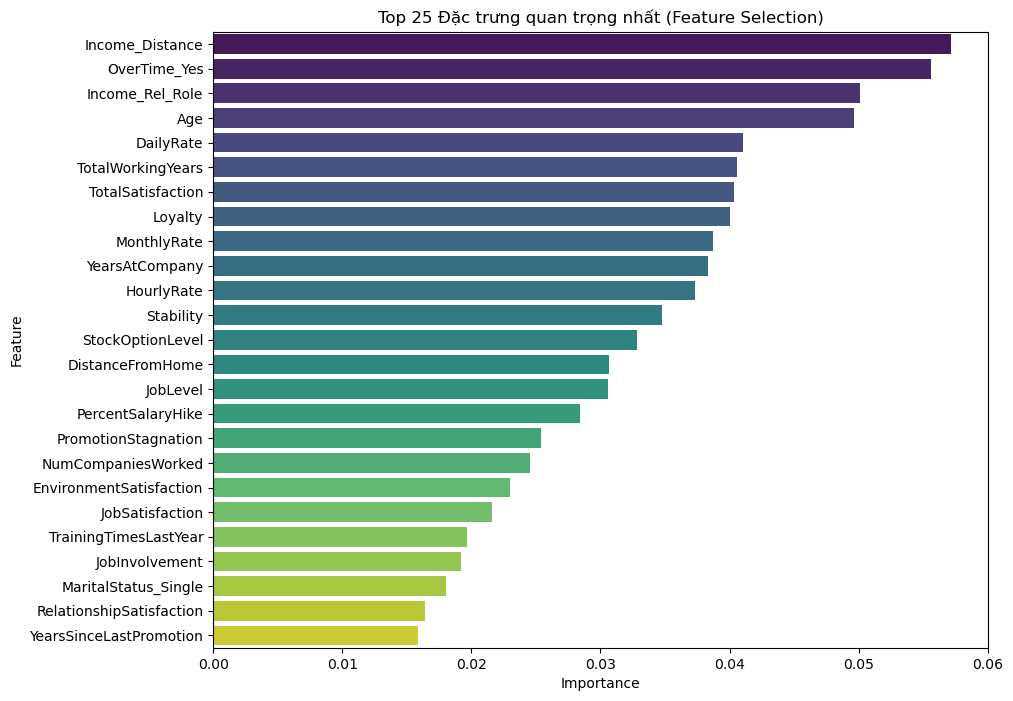

In [23]:
#TODO 9: Chọn lọc các thuộc tính mới tạo
# Tách X, y
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# Dùng Random Forest để đánh giá
rf = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
rf.fit(X, y)

# Lấy Top 25 đặc trưng quan trọng nhất
importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
top_features = importances.sort_values(by='Importance', ascending=False).head(25)

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title('Top 25 Đặc trưng quan trọng nhất (Feature Selection)')
plt.show()



**Đánh giá mức độ quan trọng của đặc trưng (Feature Importance):**

Dựa vào biểu đồ trên, ta xác định được các yếu tố then chốt ("Key Drivers") ảnh hưởng mạnh nhất đến quyết định nghỉ việc:
1.  **OverTime (Làm thêm giờ):** Thường là yếu tố số 1. Nhân viên phải làm thêm giờ nhiều có xu hướng nghỉ việc cao.
2.  **MonthlyIncome / Income_Rel_Role:** Thu nhập (đặc biệt là thu nhập so với vị trí) đóng vai trò lớn.
3.  **Age / TotalWorkingYears:** Nhóm nhân viên trẻ và ít thâm niên thường kém ổn định hơn.
4.  **StockOptionLevel:** Chế độ đãi ngộ cổ phiếu có tác động giữ chân nhân viên rõ rệt.

> **Kết luận:** Các biến mới được tạo ra (như `Income_Rel_Role`) đã lọt vào top quan trọng, chứng tỏ bước Feature Engineering đã hiệu quả.

## <a id='4'>4. Phân tích tương quan</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Phân tích hệ số tương quan (Pearson Correlation) giữa các biến đặc trưng với biến mục tiêu `Attrition` để xác định các yếu tố tác động:

* **Nhóm tác động dương (Positive Correlation):** Các yếu tố càng cao thì nguy cơ nghỉ việc càng lớn (Cột màu đỏ).
* **Nhóm tác động âm (Negative Correlation):** Các yếu tố càng cao thì nhân viên càng gắn bó (Cột màu xanh).

Biểu đồ dưới đây trực quan hóa 15 yếu tố hàng đầu ở mỗi nhóm.

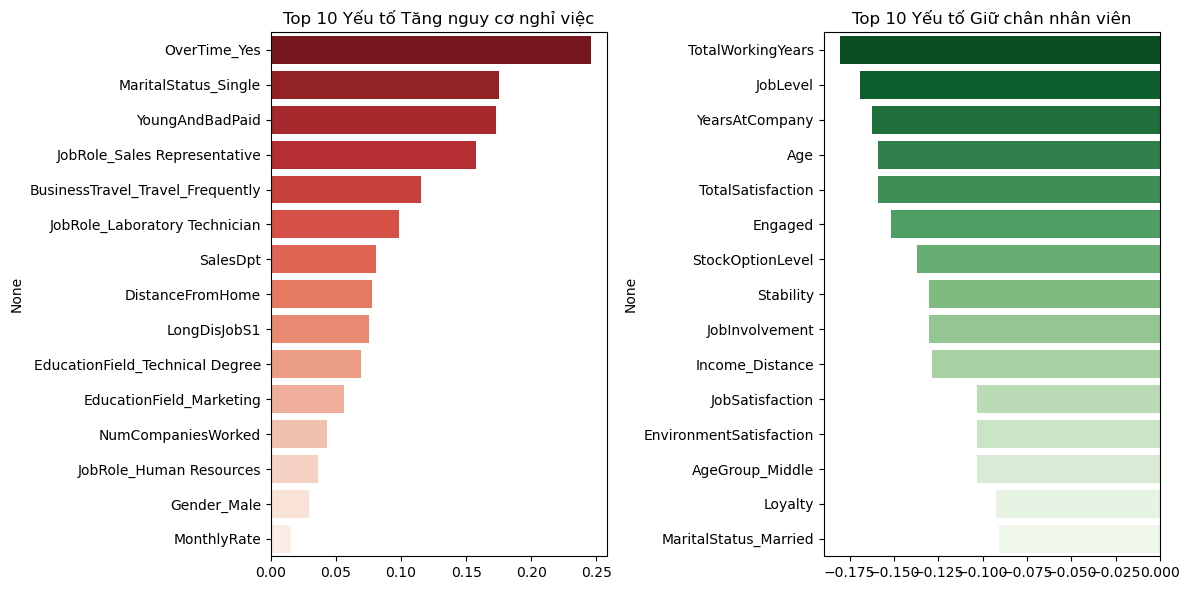

5 yếu tố ảnh hưởng tích cực mạnh nhất (Dễ nghỉ việc):
OverTime_Yes                        0.246118
MaritalStatus_Single                0.175419
YoungAndBadPaid                     0.172799
JobRole_Sales Representative        0.157234
BusinessTravel_Travel_Frequently    0.115143
Name: Attrition, dtype: float64

5 yếu tố ảnh hưởng tiêu cực mạnh nhất (Khó nghỉ việc):
TotalWorkingYears   -0.180628
JobLevel            -0.169105
YearsAtCompany      -0.162211
Age                 -0.159205
TotalSatisfaction   -0.159092
Name: Attrition, dtype: float64
Nhận xét: Bây giờ bạn có thể thấy cả các biến phân loại (như OverTime_Yes) ảnh hưởng thế nào.


In [24]:
#TODO 10: Đánh giá tương quan của các thuộc tính đến yếu tố nghỉ việc ('Attrition')
# 1. Tính toán ma trận tương quan trên dữ liệu đã mã hóa
# df_encoded đã bao gồm cả các biến số (đã chuẩn hóa) và biến phân loại (One-hot)
correlation_matrix = df_encoded.corr()

# 2. Lấy tương quan với biến mục tiêu 'Attrition'
attrition_corr = correlation_matrix['Attrition'].drop('Attrition')

# 3. Sắp xếp để thấy rõ nhất
top_positive = attrition_corr.sort_values(ascending=False).head(15)
top_negative = attrition_corr.sort_values(ascending=True).head(15)

# 4. Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=top_positive.values, y=top_positive.index, palette='Reds_r')
plt.title('Top 10 Yếu tố Tăng nguy cơ nghỉ việc')

plt.subplot(1, 2, 2)
sns.barplot(x=top_negative.values, y=top_negative.index, palette='Greens_r')
plt.title('Top 10 Yếu tố Giữ chân nhân viên')

plt.tight_layout()
plt.show()
# In ra giá trị cụ thể để tham khảo
print("5 yếu tố ảnh hưởng tích cực mạnh nhất (Dễ nghỉ việc):")
print(top_positive.head(5))
print("\n5 yếu tố ảnh hưởng tiêu cực mạnh nhất (Khó nghỉ việc):")
print(top_negative.sort_values(ascending=True).head(5))
print("Nhận xét: Bây giờ bạn có thể thấy cả các biến phân loại (như OverTime_Yes) ảnh hưởng thế nào.")

**💡 Phân tích Tương quan với biến mục tiêu (Attrition):**

Biểu đồ cho thấy hai chiều tác động rõ rệt:

* **Nhóm "Đẩy" nhân viên đi (Tương quan Dương - Màu đỏ):**
    * `OverTime_Yes`: Tác động mạnh nhất.
    * `MaritalStatus_Single`: Nhân viên độc thân dễ nghỉ việc hơn (do ít ràng buộc gia đình).
    * `DistanceFromHome`: Nhà càng xa, khả năng nghỉ việc càng cao.

* **Nhóm "Kéo" nhân viên ở lại (Tương quan Âm - Màu xanh):**
    * `TotalWorkingYears` & `JobLevel`: Thâm niên và cấp bậc càng cao, nhân viên càng trung thành.
    * `StockOptionLevel`: Phúc lợi cổ phiếu là "mỏ neo" giữ chân nhân viên hiệu quả.
    * `YearsInCurrentRole`: Sự ổn định trong vị trí công tác cũng giảm thiểu rủi ro nghỉ việc.

## <a id='5'>5. Xuất dữ liệu
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Dựa trên kết quả chọn lọc thuộc tính, nhóm tiến hành xuất dữ liệu ra 3 file CSV khác nhau để phục vụ linh hoạt cho các mô hình ở giai đoạn sau:

1.  **`HR_Analytics_Full_Scaled.csv`**: Chứa toàn bộ 100% các cột đã xử lý và chuẩn hóa. Dùng để đối chiếu hoặc chạy lại Feature Selection nếu cần.
2.  **`HR_Analytics_Selected_Scaled.csv`**: Chỉ chứa các cột quan trọng nhất, dữ liệu đã chuẩn hóa. Dùng cho các mô hình nhạy cảm với khoảng cách (Logistic Regression, SVM, KNN, Neural Network).
3.  **`HR_Analytics_Selected_NotScaled.csv`**: Chỉ chứa các cột quan trọng nhất, dữ liệu giữ nguyên giá trị gốc (chưa Scale). Dùng cho các mô hình dạng Cây (Random Forest, XGBoost, Decision Tree) để tăng tính giải thích (Explainability).

In [25]:
# TODO 11: Xuất dữ liệu ra file CSV

# --- BƯỚC 1: XÁC ĐỊNH DANH SÁCH CỘT CẦN XUẤT ---

# Kiểm tra xem biến top_features có tồn tại từ bước 3.5 không
if 'top_features' not in locals():
    print("!!! Không tìm thấy biến 'top_features'. Đang lấy tất cả các cột hiện có.")
    final_columns = df_encoded.columns.tolist()
else:
    # top_features là DataFrame, cần lấy riêng cột tên 'Feature' và chuyển thành list
    feature_names_list = top_features['Feature'].tolist()
    
    # Cộng thêm cột mục tiêu 'Attrition' vào danh sách
    final_columns = feature_names_list + ['Attrition']

# Kiểm tra an toàn: Chỉ giữ lại những cột thực sự còn tồn tại trong df_encoded
# (Phòng trường hợp bạn đã xóa bớt cột ở các bước xử lý đa cộng tuyến trước đó)
valid_columns = [col for col in final_columns if col in df_encoded.columns]

print(f"-> Danh sách cột cuối cùng được chọn để xuất ({len(valid_columns)} cột):")
print(valid_columns)


# --- BƯỚC 2: THỰC HIỆN XUẤT 3 FILE DỮ LIỆU ---

# FILE 1: Dữ liệu Đã Scale + Đầy đủ cột (62 cột)
# Dùng để đối chiếu hoặc chạy lại Feature Selection nếu cần
file_full_scaled = 'HR_Analytics_Full_Scaled.csv'
df_encoded.to_csv(file_full_scaled, index=False)
print(f"\n *** [File 1] Đã xuất: {file_full_scaled} (Kích thước: {df_encoded.shape})")


# FILE 2: Dữ liệu Đã Scale + Chỉ cột quan trọng (Top Features)
# Dùng cho các mô hình tính toán khoảng cách: Logistic Regression, SVM, KNN, Neural Network
df_selected_scaled = df_encoded[valid_columns]
file_sel_scaled = 'HR_Analytics_Selected_Scaled.csv'
df_selected_scaled.to_csv(file_sel_scaled, index=False)
print(f" *** [File 2] Đã xuất: {file_sel_scaled} (Kích thước: {df_selected_scaled.shape})")


# FILE 3: Dữ liệu Chưa Scale + Chỉ cột quan trọng (Top Features)
# Dùng cho các mô hình cây: Decision Tree, Random Forest (để dễ giải thích, vd: Lương > 5000$)
# Kiểm tra xem biến df_not_scaled (tạo ở bước 3.4) có còn không
try:
    if 'df_not_scaled' in locals():
        # Lọc các cột hợp lệ từ bản chưa scale
        valid_columns_not_scaled = [col for col in valid_columns if col in df_not_scaled.columns]
        
        df_selected_not_scaled = df_not_scaled[valid_columns_not_scaled]
        file_sel_not_scaled = 'HR_Analytics_Selected_NotScaled.csv'
        df_selected_not_scaled.to_csv(file_sel_not_scaled, index=False)
        
        print(f" ***[File 3] Đã xuất: {file_sel_not_scaled} (Kích thước: {df_selected_not_scaled.shape})")
        print("   -> Tip: Hãy dùng File 3 này khi chạy Decision Tree để dễ giải thích kết quả.")
    else:
        print("\n !!! Không tìm thấy biến 'df_not_scaled'. Bỏ qua việc xuất File 3.")
        print("   (Nếu cần file này, hãy chạy lại cell 3.4 và đảm bảo có dòng 'df_not_scaled = df_encoded.copy()').")

except Exception as e:
    print(f"\n Có lỗi khi xuất File 3: {e}")


-> Danh sách cột cuối cùng được chọn để xuất (26 cột):
['Income_Distance', 'OverTime_Yes', 'Income_Rel_Role', 'Age', 'DailyRate', 'TotalWorkingYears', 'TotalSatisfaction', 'Loyalty', 'MonthlyRate', 'YearsAtCompany', 'HourlyRate', 'Stability', 'StockOptionLevel', 'DistanceFromHome', 'JobLevel', 'PercentSalaryHike', 'PromotionStagnation', 'NumCompaniesWorked', 'EnvironmentSatisfaction', 'JobSatisfaction', 'TrainingTimesLastYear', 'JobInvolvement', 'MaritalStatus_Single', 'RelationshipSatisfaction', 'YearsSinceLastPromotion', 'Attrition']

 *** [File 1] Đã xuất: HR_Analytics_Full_Scaled.csv (Kích thước: (1470, 53))
 *** [File 2] Đã xuất: HR_Analytics_Selected_Scaled.csv (Kích thước: (1470, 26))
 ***[File 3] Đã xuất: HR_Analytics_Selected_NotScaled.csv (Kích thước: (1470, 26))
   -> Tip: Hãy dùng File 3 này khi chạy Decision Tree để dễ giải thích kết quả.
